In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_excel("C:\\Users\\RYZEN\\Downloads\\swiggy_data.xlsx")

In [18]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [19]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [20]:
print("no of rows:",df.shape[0])

no of rows: 197430


In [21]:
print("no of column:",df.shape[1])

no of column: 10


In [22]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

In [23]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [24]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [25]:
# Total Sales
total_sales = df["Price (INR)"].sum()
print("Total Sales (INR):", round(total_sales, 2))

# Average Rating
average_rating = df["Rating"].mean()
print("Average Rating:", round(average_rating, 2))

# Ratings Count
sum_of_ratings = df["Rating"].sum()
print("Ratings Count:", sum_of_ratings)

# Avg Order Value
average_order_value = df["Price (INR)"].mean()
print("Avg Order Value:", round(average_order_value, 2))

# Total Orders
print("Total Orders:", len(df))

Total Sales (INR): 53012505.77
Average Rating: 4.34
Ratings Count: 857158.5
Avg Order Value: 268.51
Total Orders: 197430


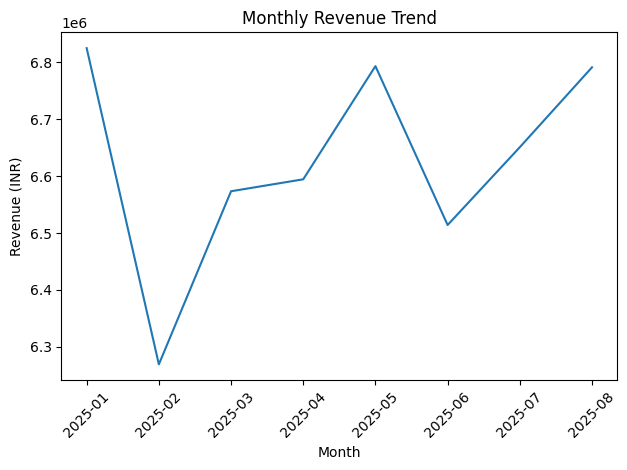

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert Order Date to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Create YearMonth period string
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

# Group by YearMonth and sum the Price (INR)
monthly_revenue = (
    df.groupby("YearMonth")["Price (INR)"].sum().reset_index()
)

# Plotting the Monthly Revenue Trend
plt.figure()
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

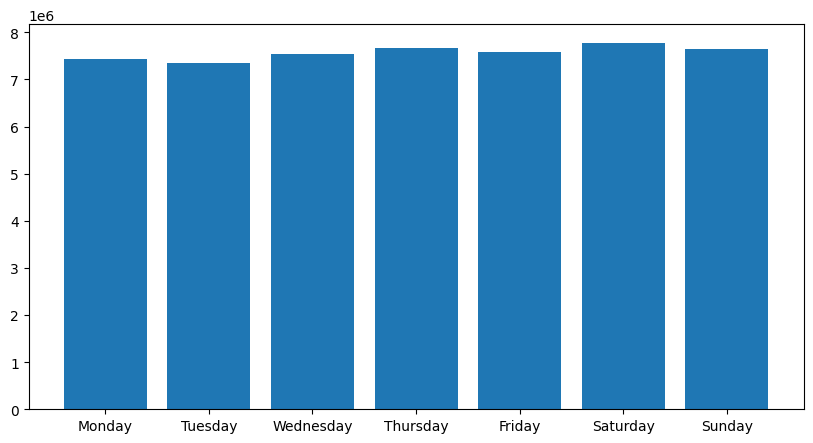

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert Order Date to datetime format and extract day name
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["DayName"] = df["Order Date"].dt.day_name()

# Order list for chronological reindexing
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

# Group by DayName, sum Price (INR), and reindex
daily_revenue = (
    df.groupby("DayName")["Price (INR)"].sum().reindex(day_order)
)

# Plotting the Daily Revenue Trend
plt.figure(figsize=(10, 5))
bars = plt.bar(
    daily_revenue.index, daily_revenue.values,)

In [28]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"]
    .sum()
    .sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State (INR)",
)

fig.update_layout(
    height=600, yaxis=dict(autorange="reversed")
)
fig.show()

In [29]:
non_veg_keywords = [
    "chicken",
    "egg",
    "fish",
    "mutton",
    "prawn",
    "biryani",
    "kabab",
    "kebab",
    "non-veg",
    "non veg",
]

df["Food Category"] = np.where(
    df["Dish Name"]
    .str.lower()
    .str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg",
)

food_revenue = (
    df.groupby("Food Category")["Price (INR)"].sum().reset_index()
)

import plotly.express as px

fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg",
)

fig.update_traces(textinfo="percent+label", pull=[0.05, 0])

fig.update_layout(
    height=500,
    margin=dict(t=60,b=40,l=40,r=40)
)
fig.show()

In [30]:
# Quarterly Trend
quarterly_summary = (df.assign(
        Order_Date=pd.to_datetime(df["Order Date"]),
        Quarter=lambda x: x["Order_Date"].dt.to_period("Q").astype(str)
    )
    .groupby("Quarter", as_index=False)
    .agg(
        Total_Sales=("Price (INR)", "sum"),
        Avg_Rating=("Rating", "mean"),
        Total_Orders=("Order_Date", "count")
    )
    .sort_values("Quarter")
)

quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


In [31]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)

fig.show()

In [33]:
df["Week Number"] = pd.to_datetime(df["Order Date"]).dt.isocalendar().week

weekly_revenue = (
    df.groupby("Week Number")["Price (INR)"]
    .sum()
    .reset_index()
)

fig = px.bar(
    weekly_revenue,
    x="Week Number",
    y="Price (INR)",
    title="Weekly Revenue Trend",
    color_discrete_sequence=["violet"]
)

fig.show()